# Land Use and Land Cover Classification using Pytorch
land use and land cover (LULC) classification using Pytorch!

- train a deep learning model for image classification using Pytorch
- generate land use and land cover maps using Python GIS



<a name="overview"></a>
# Overview
 An introduction to image classification using Pytorch for land use and land cover (LULC) mapping.

Specifically
- classify satellite images into 10 LULC categories using the [EuroSAT dataset](https://arxiv.org/abs/1709.00029)
- fine-tune a Resnet-50 CNN model for image classification
- save and load trained models in Pytorch




<a name="climate-impact"></a>
# Climate Impact
A [report](https://www.wri.org/insights/7-things-know-about-ipccs-special-report-climate-change-and-land) by the World Resources Institute (WRI) states that about 23% of global human-caused GHG emissions come from land uses such as agriculture, forestry, and urban expansion. Land use change such as deforestation and land degradation are among the primary drivers of these emissions. Rapid urbanization leading to an increase in built-up areas as well as a massive loss of terrestrial carbon storage can also result in large carbon emissions.

Mapping the extent of land use and land cover categories over time is essential for better environmental monitoring, urban planning and nature protection. For example, monitoring changes in forest cover and identifying drivers of forest loss can be useful for forest conservation and restoration efforts. Assessing the vulnerability of certain land cover types, such as settlements and agricultural land, to certain risks can also be useful for for disaster risk reduction planning as well as long-term climate adaptation efforts.

With the increasing availability of earth observation data coupled with recent advanced in computer vision, AI & EO has paved the way for the potential to map land use and land cover at an unprecedented scale. In this tutorial, we will explore the use of Sentinel-2 satellite images and deep learning models in Pytorch to automate LULC mapping.

<br>
<center><p><p> <img src="https://ptes.org/wp-content/uploads/2018/04/iStock-664630460-e1524839082464.jpg" alt="alt" width="50%"/>




<a name="software-requirements"></a>
# Software Requirements

This notebook requires Python >= 3.7. The following libraries are required:
*   tqdm
*   pandas
*   numpy
*   matplotlib
*   pytorch

In [ ]:
# Standard libraries
import os
import random
from tqdm.notebook import tqdm

# Data manipulation and visualization
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
import pandas as pd
import numpy as np

# Deep Learning libraries
import torch
import torchvision
import torchsummary
from torch.utils import data
from torchvision import datasets, models, transforms

# Set seed for reproducibility
SEED = 42
np.random.seed(SEED)

## Google Colab GPU
Check that the GPU  enabled in your colab notebook by running the cell below.

In [ ]:
# Check is GPU is enabled
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device: {}".format(device))

# Get specific GPU model
if str(device) == "cuda:0":
  print("GPU: {}".format(torch.cuda.get_device_name(0)))

Device: cuda:0
GPU: Tesla T4


## Mount Drive

Mounting the drive will allow the Google Colab notebook to load and access files from your Google drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<a name="data-description"></a>
# Data Description

In this section:
- Download the EuroSAT dataset into your Google Drive
- Generate the train and test sets by splitting the EuroSAT dataset
- Visualize a sample of the images and their LULC labels

## EuroSAT Dataset
The [EuroSAT dataset](https://github.com/phelber/EuroSAT) contains 27,000 labelled 64x64 pixel Sentinel-2 satellite image patches with 10 different LULC categories. Both RGB and multi-spectral (MS) images are available for download. For simplicity, we will focus on RGB image classification.

In [ ]:
!wget http://madm.dfki.de/files/sentinel/EuroSAT.zip -O EuroSAT.zip
!unzip -q EuroSAT.zip -d 'EuroSAT/'
!rm EuroSAT.zip

--2026-03-25 09:37:26--  http://madm.dfki.de/files/sentinel/EuroSAT.zip
Resolving madm.dfki.de (madm.dfki.de)... 131.246.195.183
Connecting to madm.dfki.de (madm.dfki.de)|131.246.195.183|:80... connected.
HTTP request sent, awaiting response... 403 Forbidden
2026-03-25 09:37:26 ERROR 403: Forbidden.

[EuroSAT.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of EuroSAT.zip or
        EuroSAT.zip.zip, and cannot find EuroSAT.zip.ZIP, period.


In [ ]:
!unzip -q EuroSAT.zip -d EuroSAT
!ls EuroSAT

In [ ]:
from torchvision.datasets import EuroSAT
dataset = EuroSAT(root='./data', download=True)

100%|██████████| 94.3M/94.3M [00:00<00:00, 365MB/s]


In [ ]:
from torch.utils.data import Subset
import numpy as np

# Take 5000 samples only
indices = np.random.choice(len(dataset), 5000, replace=False)
small_dataset = Subset(dataset, indices)

print(len(small_dataset))

5000


## Generate Train and Test Sets

### Create Custom Dataset Class
In Pytorch, the `Dataset` class allows you to define a custom class to load the input and target for a dataset. used this capability to load in our inputs in the form of RGB satellite images along with their corresponding labels. Later how to apply necessary image transformations.

In [ ]:
class EuroSAT(data.Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.dataset[index]   # FIXED

        if self.transform:
            x = self.transform(x)

        return x, y

    def __len__(self):
        return len(self.dataset)   # FIXED

In [ ]:
input_size = 224
imagenet_mean, imagenet_std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(input_size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

val_transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

test_transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

### Load EuroSAT Dataset
Loading the EuroSAT dataset using torch's `ImageFolder` class.

`ImageFolder` is a generic data loader where the images are arranged in this way:

```
    data
    └───AnnualCrop
    │   │   AnnualCrop_1.jpg
    │   │   AnnualCrop_2.jpg
    │   │   AnnualCrop_3.jpg
    │   │   ...
    └───Forest
    │   │   Forest_1.jpg
    │   │   Forest_2.jpg
    │   │   Forest_3.jpg
    │   │   ...
```


In [ ]:
class_names = dataset.classes
print("Class names:", class_names)
print("Total number of classes:", len(class_names))

Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total number of classes: 10


### Split into Train, Validation, and Test Sets
Here, we split the dataset into a train set and test set. The training set will be 70% of the Eurosat dataset, randomly selected. We set aside 15% of the dataset as our validation set and the remaining 15% as our test set.

In [ ]:
from torch.utils.data import random_split

train_size = int(0.7 * len(small_dataset))
val_size = int(0.15 * len(small_dataset))
test_size = len(small_dataset) - train_size - val_size

train_subset, val_subset, test_subset = random_split(
    small_dataset, [train_size, val_size, test_size]
)

print(len(train_subset), len(val_subset), len(test_subset))

3500 750 750


In [ ]:
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

In [ ]:
train_data = TransformedSubset(train_subset, train_transform)
val_data = TransformedSubset(val_subset, val_transform)
test_data = TransformedSubset(test_subset, test_transform)

Finally, we use `torch`'s `DataLoader` class to create a dataloader.  The dataloader manages fetching samples from the datasets (it can even fetch them in parallel using `num_workers`) and assembles batches of the datasets.

In [ ]:
num_workers = 2
batch_size = 16

train_loader = data.DataLoader(
    train_data, batch_size=batch_size, num_workers=num_workers, shuffle=True
)
val_loader = data.DataLoader(
    val_data, batch_size=batch_size, num_workers=num_workers, shuffle=False
)
test_loader = data.DataLoader(
    test_data, batch_size=batch_size, num_workers=num_workers, shuffle=False
)

## Visualize Data

In the cell below, we will visualize a batch of the dataset.  The cell visualizes the input to the neural network (the RGB image) along with the associated label.

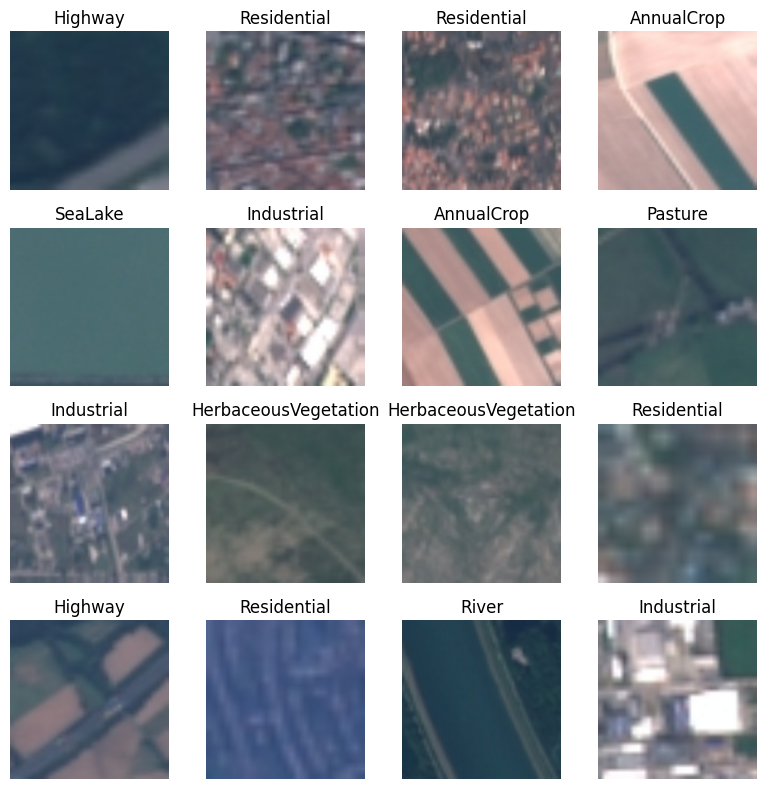

In [ ]:
n = 4
inputs, classes = next(iter(train_loader))
fig, axes = plt.subplots(n, n, figsize=(8, 8))

for i in range(n):
    for j in range(n):
        image = inputs[i * n + j].numpy().transpose((1, 2, 0))
        image = np.clip(np.array(imagenet_std) * image + np.array(imagenet_mean), 0, 1)

        title = class_names[classes[i * n + j]]
        axes[i, j].imshow(image)
        axes[i, j].set_title(title)
        axes[i, j].axis('off')

plt.tight_layout()

# Exploratory Data Analysis

Next, let's explore our dataset a little bit more.  In particular, how many images of each class are included?

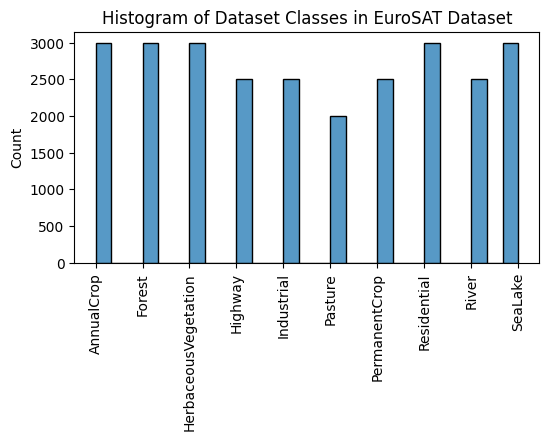

In [ ]:
targets = [dataset[i][1] for i in range(len(dataset))]
plt.figure(figsize=(6, 3))
hist = sns.histplot(targets)

hist.set_xticks(range(len(dataset.classes)))
hist.set_xticklabels(dataset.classes, rotation=90)
hist.set_title('Histogram of Dataset Classes in EuroSAT Dataset')

plt.show()

# Model Development

## Instantiate Model

 Used a standard neural network architecture, called ResNet50. Based on [the work by Helber et al.](https://arxiv.org/pdf/1709.00029.pdf), ResNet-50 has been shown to work well for LULC classification on the EuroSAT

### ResNet-50
<b>Recall</b>: Deep neural networks are difficult to train due to the problem of vanishing or exploding gradients (repeated multiplication making the gradient infinitively small). ResNet solves this by using shortcut connections that connect activation from an earlier layer to a further layer by skipping one or more layers as shown below. This allows for gradients to propagate to the deeper layers before they can be reduced to small or zero values.
<br><br>

<center> <img src="https://jananisbabu.github.io/ResNet50_From_Scratch_Tensorflow/images/resnet50.png" width="600"/><br>
Image source: <a href="https://jananisbabu.github.io/ResNet50_From_Scratch_Tensorflow/">https://jananisbabu.github.io/ResNet50_From_Scratch_Tensorflow/  </a>
</center>
<br>

Note that when we load the model, we set the `weights=models.ResNet50_Weights.DEFAULT` to indicate that the loaded model should be already pre-trained on the Imagenet dataset. We also modify the final layer so that the output matches the number of classes in our dataset.

In [ ]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = torch.nn.Linear(model.fc.in_features, len(dataset.classes))
model = model.to(device)
torchsummary.summary(model, (3, 224, 224))

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

## Model Training and Evaluation
Proceed to model training and evaluation.

This section has three major parts:

1. Specify the criterion, optimizer, and hyperparameters (e.g. n_epochs, learning rate, etc.).
2. Train the model on the training set by updating its weights to minimize the loss function.
3. Evaluate the model on the test set to observe performance on new, unseen data.
4. Repeat steps 2 and 3 `n_epochs` times.

### Cross Entropy Loss
We define our loss as the cross-entropy loss, which measures the performance of a classification model whose output is a probability value between 0 and 1. Cross-entropy loss increases as the predicted probability diverges from the actual label. ([Source](https://ml-cheatsheet.readthedocs.io/en/latest/loss_functions.html))

For two classes, it is computed as:

$−ylog(p)-(1−y)log(1−p)$

For multiclass classification with $M$ classes, it is defined as:

$−\sum_{c=1}^{M}y_{o,c}log(p_{o,c})$

where

- $M$ - number of classes (dog, cat, fish)
- $log$ - the natural log
- $y_{o,c}$ - binary indicator (0 or 1) if class label $c$ is the classification for observation $o$
- $p_{o,c}$- predicted probability observation $o$ is of class $c$

### Stochastic Gradient Descent
Remember that the goal of stochastic gradient descent (SGD) is to minimize the loss function. To do this, it computes the slope (gradient) of the loss function at the current point and moves in the opposite direction of the slope towards the steepest descent.
<center> <img src="https://miro.medium.com/max/1400/1*P7z2BKhd0R-9uyn9ThDasA.png" width="350"/><br>Image source:
<a href="https://towardsdatascience.com/batch-mini-batch-stochastic-gradient-descent-7a62ecba642a">https://towardsdatascience.com/batch-mini-batch-stochastic-gradient-descent-7a62ecba642a</a>
</center>
<br>

In [ ]:
# Specify number of epochs and learning rate
n_epochs = 15
lr = 1e-3

# Specify criterion and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

Next. let's create our training function.

In [ ]:
def train(model, dataloader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    running_total_correct = 0

    for inputs, labels in tqdm(dataloader):
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)

        running_loss += loss.item() * inputs.size(0)
        running_total_correct += torch.sum(preds == labels).item()

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_accuracy = (running_total_correct / len(dataloader.dataset)) * 100

    print(f"Train Loss: {epoch_loss:.2f}; Accuracy: {epoch_accuracy:.2f}")

    return epoch_loss, epoch_accuracy

Next, let's define the model evaluation function.

In [ ]:
def evaluate(model, dataloader, criterion, phase="val"):
    model.eval()

    running_loss = 0.0
    running_total_correct = 0

    for inputs, labels in tqdm(dataloader):
        inputs = inputs.to(device)
        labels = labels.to(device)

        with torch.no_grad():   # cleaner than set_grad_enabled(False)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

        running_loss += loss.item() * inputs.size(0)
        running_total_correct += torch.sum(preds == labels).item()

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_accuracy = (running_total_correct / len(dataloader.dataset)) * 100

    print(f"{phase.title()} Loss: {epoch_loss:.2f}; Accuracy: {epoch_accuracy:.2f}")

    return epoch_loss, epoch_accuracy

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


In [ ]:
class_names = ['Annual Crop', 'Forest', 'Herbaceous Veg', 'Highway', 'Industrial',
               'Pasture', 'Permanent Crop', 'Residential', 'River', 'Sea Lake']


Putting it all together, we define the `fit` function for training and evaluating the model on the training set and validation set, respectively.

In [ ]:
import copy

def fit(model, train_loader, val_loader, n_epochs, lr, criterion, optimizer):
    best_loss = np.inf
    best_model = None

    for epoch in range(n_epochs):
        print(f"\nEpoch {epoch+1}/{n_epochs}")

        train(model, train_loader, criterion, optimizer)
        val_loss, _ = evaluate(model, val_loader, criterion)

        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model)   # FIXED

    return best_model

We can now commence model training and evaluation in the following cell.

In [ ]:
best_model = fit(model, train_loader, val_loader, n_epochs, lr, criterion, optimizer)


Epoch 1/15


  0%|          | 0/219 [00:00<?, ?it/s]

Train Loss: 2.20; Accuracy: 29.26


  0%|          | 0/47 [00:00<?, ?it/s]

Val Loss: 2.13; Accuracy: 42.53

Epoch 2/15


...

Val Loss: 0.54; Accuracy: 85.73

Epoch 15/15


  0%|          | 0/219 [00:00<?, ?it/s]

Train Loss: 0.65; Accuracy: 80.03


  0%|          | 0/47 [00:00<?, ?it/s]

Val Loss: 0.51; Accuracy: 86.80


## Model Performance on the Test Set
Using the best model from the previous steps, we can evaluate the model performance on the test set.

In [ ]:
test_loss, _ = evaluate(best_model, test_loader, criterion, phase="test")

  0%|          | 0/47 [00:00<?, ?it/s]

Test Loss: 0.50; Accuracy: 86.67


In [ ]:
y_true = []
y_pred_classes = []

best_model.eval()

with torch.no_grad():
    for inputs, labels in tqdm(val_loader):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = best_model(inputs)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred_classes.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred_classes = np.array(y_pred_classes)

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes))

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

  0%|          | 0/47 [00:00<?, ?it/s]

Confusion Matrix:
[[71  0  0  3  0  1  0  0  3  0]
 [ 0 74  1  0  0  1  0  0  0 12]
 [ 0  0 74  0  0  0  2  2  0  1]
 [ 1  0  1 58  6  2  2  0  9  0]
 [ 0  0  0  0 72  0  0 10  0  0]
 [ 0  5  1  0  0 50  0  0  0  0]
 [ 3  0  7  2  2  1 50  3  0  1]
 [ 0  0  0  0  0  0  0 76  0  0]
 [ 5  0  0  2  1  3  0  2 52  0]
 [ 0  0  0  0  0  1  0  0  3 74]]

Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.89      0.91      0.90        78
              Forest       0.94      0.84      0.89        88
HerbaceousVegetation       0.88      0.94      0.91        79
             Highway       0.89      0.73      0.81        79
          Industrial       0.89      0.88      0.88        82
             Pasture       0.85      0.89      0.87        56
       PermanentCrop       0.93      0.72      0.81        69
         Residential       0.82      1.00      0.90        76
               River       0.78      0.80      0.79        65
      

## Save Model

Let's define a function for saving the model to our local Google drive as follows.


In [ ]:
model_dir = "./drive/My Drive/Colab Notebooks/models/"
if not os.path.exists(model_dir):
  os.makedirs(model_dir)

model_file = os.path.join(model_dir, 'best_model.pth')
model_file

'./drive/My Drive/Colab Notebooks/models/best_model.pth'

In [ ]:
def save_model(best_model, model_file):
  torch.save(best_model.state_dict(), model_file)
  print('Model successfully saved to {}.'.format(model_file))

In [ ]:
save_model(best_model, model_file)

Model successfully saved to ./drive/My Drive/Colab Notebooks/models/best_model.pth.


## Load Model
Here we show you how to load the saved model from the previous step.

In [ ]:
def load_model(model_file):
  # Uncomment this to download the model file
  #if not os.path.isfile(model_file):
  #  model_file = 'best_model.pth'
  #  !gdown "13AFOESwxKmexCoOeAbPSX_wr-hGOb9YY"

  model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
  model.fc = torch.nn.Linear(model.fc.in_features, 10)
  model.load_state_dict(torch.load(model_file))
  model.eval()

  print('Model file {} successfully loaded.'.format(model_file))
  return model

In [ ]:
model = load_model(model_file)

Model file ./drive/My Drive/Colab Notebooks/models/best_model.pth successfully loaded.


<a name="results"></a>
# Results

Let's visualize an example of the neural network making a prediction.

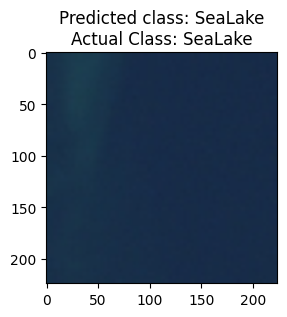

In [ ]:
# Retrieve sample image
index = 15
image, label = test_data[index]

# Predict on sample
model = model.to("cpu")
output = model(image.unsqueeze(0))
_, pred = torch.max(output, 1)

# Get corresponding class label
label = class_names[label]
pred = class_names[pred[0]]

# Visualize sample and prediction
image = image.cpu().numpy().transpose((1, 2, 0))
image = np.clip(np.array(imagenet_std) * image + np.array(imagenet_mean), 0, 1)

fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(image)
ax.set_title("Predicted class: {}\nActual Class: {}".format(pred, label));

Here, we show how to run the model on a PIL image.

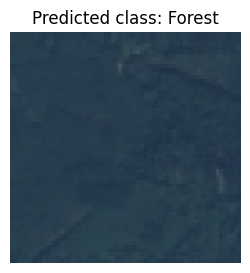

In [ ]:
from PIL import Image

image_path = '/content/data/eurosat/2750/Forest/Forest_1.jpg'
image = Image.open(image_path)

# Transform image
input_tensor = test_transform(image).unsqueeze(0).to(device)

# Set model to eval mode
best_model.eval()

with torch.no_grad():
    output = best_model(input_tensor)
    _, pred = torch.max(output, 1)

pred_class = class_names[pred.item()]

# Visualize results
fig, ax = plt.subplots(figsize=(3,3))
ax.imshow(image)
ax.set_title(f"Predicted class: {pred_class}")
ax.axis('off')

plt.show()


# Experiment with a different fine-tuning strategy.

So far, we've intialized the CNN with weights from a model train on the ImageNet data and retrained the model on the EuroSAT dataset by updating **all weights**. Another approach to fine-tuning involves using the pretrained convolutional layers as a fixed feature extractor and freezing those weights, only updating the weights of the final fully-connected layers for classification.

In [ ]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = torch.nn.Linear(model.fc.in_features, len(dataset.classes))
model = model.to(device)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Add final (unfrozen) layer for classification
model.fc = torch.nn.Linear(model.fc.in_features, len(dataset.classes))
model = model.to(device)

# Commence training
optimizer = torch.optim.SGD(model.parameters(), lr=lr)
best_model = fit(model, train_loader, val_loader, n_epochs, lr, criterion, optimizer)


Epoch 1/15


  0%|          | 0/219 [00:00<?, ?it/s]

Train Loss: 2.23; Accuracy: 25.74


  0%|          | 0/47 [00:00<?, ?it/s]

Val Loss: 2.17; Accuracy: 40.00

Epoch 2/15


...

Val Loss: 1.42; Accuracy: 64.53

Epoch 15/15


  0%|          | 0/219 [00:00<?, ?it/s]

Train Loss: 1.31; Accuracy: 65.49


  0%|          | 0/47 [00:00<?, ?it/s]

Val Loss: 1.37; Accuracy: 65.87


# Experiment with different Imagenet-pretrained CNN models.

ResNet50 is only one of many different CNN model architectures. Determining the best model architecture is an important part of the model selection process, and in practice, it's best to try out and compare different model architectures.




Here we choose EfficientNet-B0 as the model to train and evaluate. More information on

In [ ]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Modify the final layer for classification
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, len(dataset.classes))

model = model.to(device)
torchsummary.summary(model, (3, 224, 224))

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 179MB/s]


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
              SiLU-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
              SiLU-6         [-1, 32, 112, 112]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             264
              SiLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 32, 1, 1]             288
          Sigmoid-11             [-1, 32, 1, 1]               0
SqueezeExcitation-12         [-1, 32, 112, 112]               0
           Conv2d-13         [-1, 16, 112, 112]             512
      BatchNorm2d-14         [-1, 16, 1

In [ ]:
# Commence training
optimizer = torch.optim.SGD(model.parameters(), lr=lr)
best_model = fit(model, train_loader, val_loader, n_epochs, lr, criterion, optimizer)


Epoch 1/15


  0%|          | 0/219 [00:00<?, ?it/s]

Train Loss: 2.19; Accuracy: 25.20


  0%|          | 0/47 [00:00<?, ?it/s]

Val Loss: 2.06; Accuracy: 44.67

Epoch 2/15


...

Val Loss: 0.57; Accuracy: 86.00

Epoch 15/15


  0%|          | 0/219 [00:00<?, ?it/s]

Train Loss: 0.74; Accuracy: 77.89


  0%|          | 0/47 [00:00<?, ?it/s]

Val Loss: 0.53; Accuracy: 88.40


#Experiment with Satellite Image-pretrained CNN models.

Practitioners have traditionally relied on Imagenet-pretrained models for transfer learning tasks, even for Earth Observation data. However, with the increasing availability of remote sensing data, we're now seeing more and more large-scale remote sensing datasets being curated for model pre-training. Models trained on these datasets utilize unsupervised/self-supervised learning techniques, leveraging the large amounts of raw, unlabeled remote sensing data for model pretraining.



In [ ]:
!pip install -q timm
!pip install -q torchgeo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.1/688.1 kB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.6/863.6 kB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 120.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import timm
from torchgeo.models import ResNet50_Weights

weights = ResNet50_Weights.SENTINEL2_RGB_MOCO
model = timm.create_model(
    "resnet50", in_chans=weights.meta["in_chans"],
    num_classes=len(dataset.classes)
)
model.load_state_dict(weights.get_state_dict(progress=True), strict=False)

model = model.to(device)
torchsummary.summary(model, (3, 224, 224))

Downloading: "https://hf.co/torchgeo/resnet50_sentinel2_rgb_moco/resolve/efd9723b59a88e9dc1420dc1e96afb25b0630a3c/resnet50_sentinel2_rgb_moco-2b57ba8b.pth" to /root/.cache/torch/hub/checkpoints/resnet50_sentinel2_rgb_moco-2b57ba8b.pth


100%|██████████| 90.0M/90.0M [00:00<00:00, 160MB/s]


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
         Identity-10           [-1, 64, 56, 56]               0
             ReLU-11           [-1, 64, 56, 56]               0
         Identity-12           [-1, 64, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

In [ ]:
# Commence training
optimizer = torch.optim.SGD(model.parameters(), lr=lr)
best_model = fit(model, train_loader, val_loader, n_epochs, lr, criterion, optimizer)


Epoch 1/15


  0%|          | 0/219 [00:00<?, ?it/s]

Train Loss: 2.30; Accuracy: 9.23


  0%|          | 0/47 [00:00<?, ?it/s]

Val Loss: 2.30; Accuracy: 13.60

Epoch 2/15


...

Val Loss: 1.85; Accuracy: 45.73

Epoch 15/15


  0%|          | 0/219 [00:00<?, ?it/s]

Train Loss: 1.94; Accuracy: 45.34


  0%|          | 0/47 [00:00<?, ?it/s]

Val Loss: 1.77; Accuracy: 45.20
